# Paper III: SMBH binaries with PLATO

TODO: write git version of last functional run!

In [132]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC 
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [135]:
path = '/lhome/nicholas/software/workdir/cs-smbhb'

---
## Variable sources
---

### Generate files

In [4]:
hpc = HPC(cpus=6)
paramFile = f'{path}/data_varsource.txt'
# hpc.run(script='varsim', project='smbhb', paramFile=paramFile)

### Preview files

In [136]:
starID = f'{1}'.zfill(9)
df = pd.read_csv(f'{path}/varsource/varsource_{starID}.txt', sep=' ', names=['time', 'mag']) 

<IPython.core.display.Javascript object>


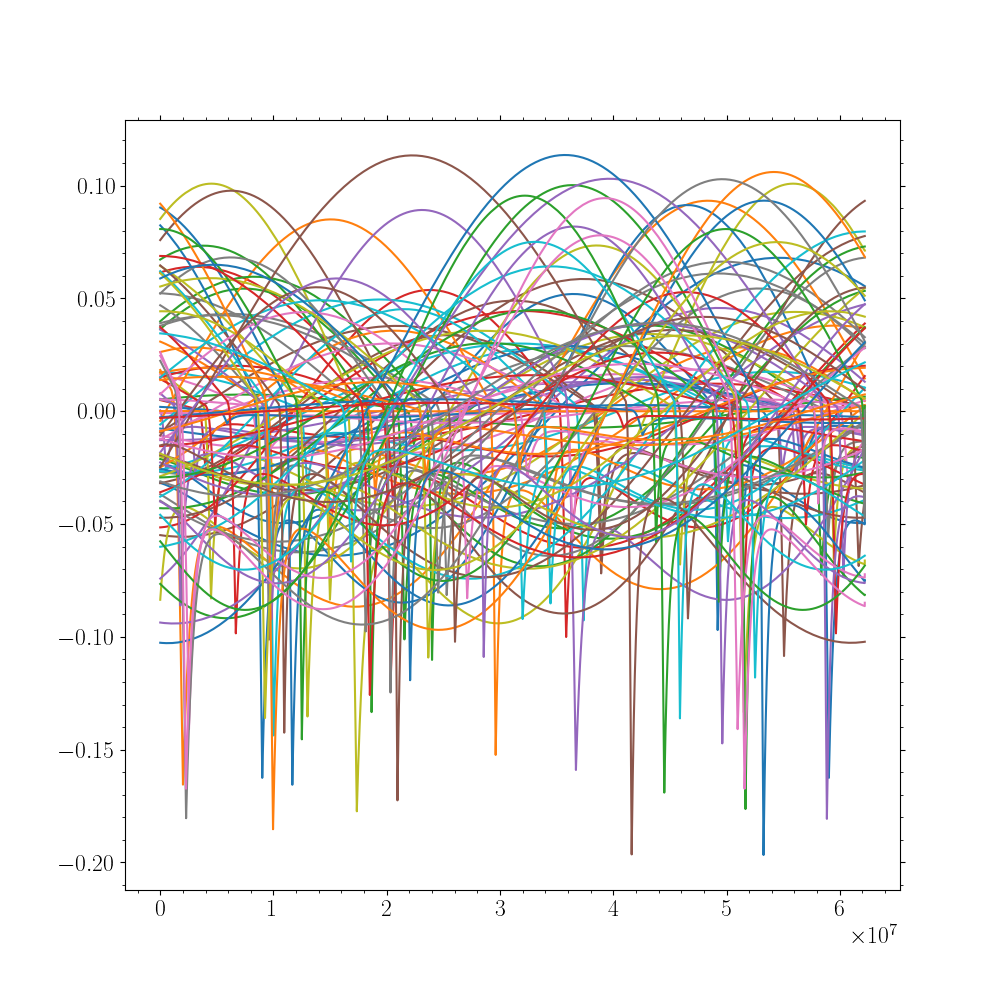

In [10]:
plt.figure(figsize=(10,10))
for i in range(100):
    starID = f'{i+1}'.zfill(9)
    df = pd.read_csv(f'{path}/varsource/varsource_{starID}.txt', sep=' ', names=['time', 'mag'])    
    plt.plot(df.time, df.mag)

### Add magnitude column parameterisation file

In [137]:
starcat = f'{path}/input/starcat_P5_SPF_Ncam24_targets.ftr'
df = pd.read_feather(starcat)

In [16]:
# Generate 1000 random magnitudes reproducable using the seed=1000
rng = np.random.default_rng(seed=1000)
mag = rng.uniform(16, 19, 1000)

# Replace magnitude column in target catalogue
df.mag = mag
df = df.astype({'mag':np.float32})
df.head()

,index,ID,PIC,ra,dec,mag,sample,Teff,R,M,ncams,field,ncon
0,0,000000001,11571238,95.125555,-47.494494,17.564157,8,6322.698412,1.353938,1.240897,24,S,3
1,1,000000002,10612872,88.125215,-49.637731,17.811525,8,5133.584125,4.040686,1.500600,24,S,0
2,2,000000003,16373342,81.625712,-36.698203,17.412825,8,5864.912195,1.276711,1.123527,24,S,1
3,3,000000004,10090932,75.739371,-50.792750,16.609743,8,6264.024256,1.685365,1.331812,24,S,1
4,4,000000005,7792932,89.211789,-55.354966,17.586277,8,6108.070185,2.217076,1.434869,24,S,1


In [18]:
df.to_feather(starcat)

---
## VSC overview
---

In [22]:
path = '/lhome/nicholas/server/data/workdir/smbhb/slurmTest'
paramFile = f'{path}/cluster.data'

<IPython.core.display.Javascript object>


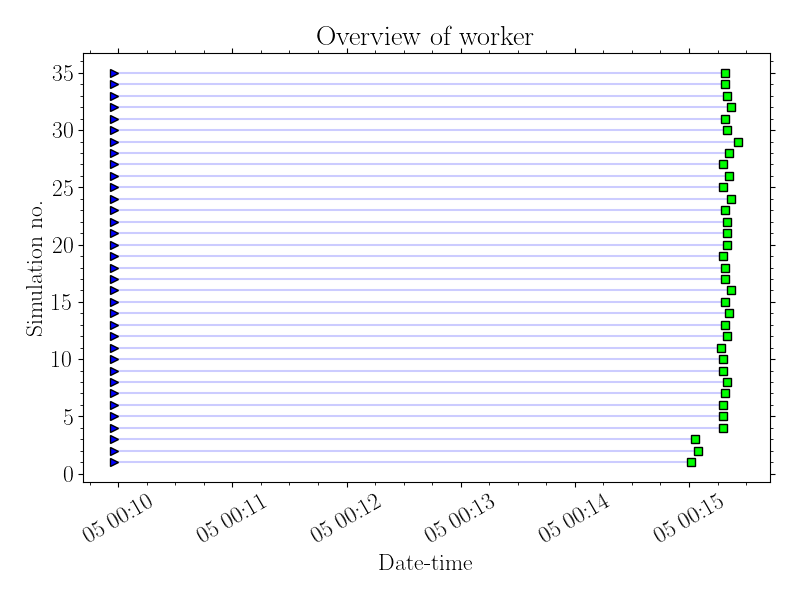

All simulations finished successfully!


In [23]:
workerLog = f'{path}/run.pbs.log55286817'
workerOverview(workerLog, paramFile, ofile=False, plot=True)

---
## Simulation statistics
---

In [4]:
# lcs1 = LightCurve(f'{idir}/P1/lightcurve', mode='multi')
# lcs5 = LightCurve(f'{idir}/P5/lightcurve_without_maskupdate', mode='multi')

### Table of all simulated LCs

In [6]:
# df1 = lcs1.stat_sims()
# df1.head()

In [7]:
# df5 = lcs5.stat_sims()
# df5.head()

### LCs per star and quarter

In [9]:
# lcs1.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP1.txt')

In [10]:
# lcs.stat_lcsPerStar(quarters=[23,24], ofile='stat_simsPerStarP5.txt')

## LCs per N-CAM

In [11]:
# from platosim.hpc import HPC 
# hpc = HPC(cpus=8)
# # hpc.run(script='platonium', project='kul20', paramFile=paramFile)

In [12]:
# statFile = '/lhome/nicholas/software/workdir/kul20/statistics.txt'
# df = pd.read_csv(statFile)

In [13]:
# df = df.rename(columns={'1': 'star', '1.1':'group', '1.2':'camera', '24':'quarter', '1.3':'flag'})

In [14]:
# df[df.flag == 0]

---
## Merge light curves
---

### Single camera light curve

In [39]:
lcs = LightCurve(f'{path}/output/000000001', mode="multi")
lcs.unpack()

In [40]:
# Load all files for a single camera
files = lcs.files('hdf5', group=1, camera=1)
lc = LightCurve(files[0])

In [41]:
# Load input model
dv = lc.varsource()

In [42]:
# Load info about simulation
ds = lc.star()
ds

ID                   1
PIC           11571238
ra           95.125555
dec         -47.494494
mag          17.564157
group                1
camera               1
quarter              1
rOA           4.332506
xFP         -17.996888
yFP          -5.269025
ccd                  2
xCCD        220.501372
yCCD       3582.395116
ncon                 3
Name: 0, dtype: object

In [166]:
# Combine light curves
df = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1['time'] = lc.time()
    df1['flux'] = lc.flux(unit='ppt')
    df = pd.concat([df, df1])

<IPython.core.display.Javascript object>


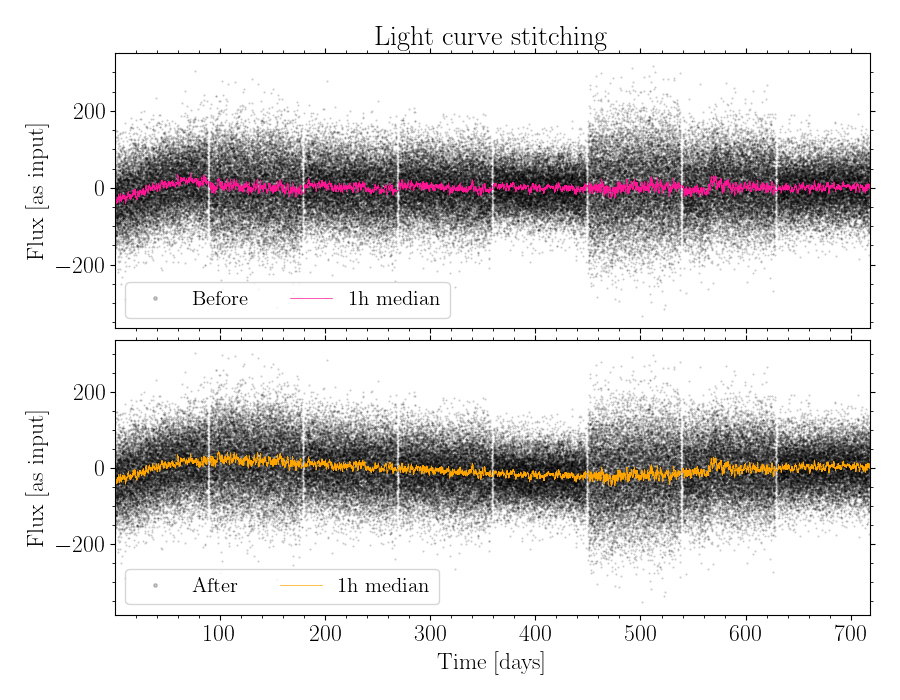

In [167]:
# Stitch the light curve
lc = LightCurve(df, mode="multi")
df = lc.stitch(plot=True)

In [168]:
# Calculate median filter
carbox = int(2*24*3600/600)
flux = df.flux_stitch
fmed = median_filter(flux, carbox)
df

,time,flux,flux_stitch
0,6.25,29.687730,29.687730
1,606.25,46.062025,46.062025
2,1206.25,-3.274560,-3.274560
3,1806.25,-33.284486,-33.284486
4,2406.25,1.181185,1.181185
...,...,...,...
12667,62032206.25,61.254754,63.768904
12668,62032806.25,-50.378695,-47.864544
12669,62033406.25,-49.433011,-46.918861
12670,62034006.25,-30.359802,-27.845652


<IPython.core.display.Javascript object>


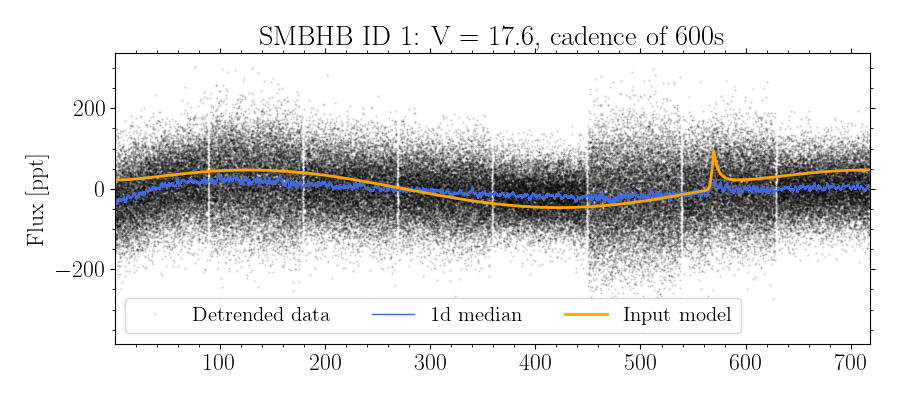

In [150]:
# Change time [days]
time   = df.time / 86400.
t_smbh = dv.time / 86400.

# Plot comparison figure
fig, ax = plt.subplots(1, 1, figsize=(9,4))
plt.plot(time, flux,      '.', c='k',         ms=1, label='Detrended data', alpha=0.2)
plt.plot(time, fmed,      '-', c='royalblue', lw=1, label='1d median')
plt.plot(t_smbh, dv.flux, '-', c='orange',    lw=2, label='Input model')
plt.title(f'SMBHB ID {ds.ID}: V = {ds.mag:.3}, cadence of 600s')
plt.ylabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(np.min(time), np.max(time))
plt.legend(ncol=3, loc='lower left')
plt.tight_layout();

### Combined camera light curve

In [125]:
no = 1
lcs = LightCurve(f'{path}/output/'+f'{no}'.zfill(9), mode="multi")
lcs.unpack()

In [126]:
# Load input model
lc = LightCurve(lcs.files('hdf5')[0])
dv = lc.varsource()
ds = lc.star()
ds

ID                   1
PIC           11571238
ra           95.125555
dec         -47.494494
mag          17.564157
group                1
camera               1
quarter              1
rOA           4.332506
xFP         -17.996888
yFP          -5.269025
ccd                  2
xCCD        220.501372
yCCD       3582.395116
ncon                 3
Name: 0, dtype: object

In [127]:
df = lcs.merge_star()

<IPython.core.display.Javascript object>


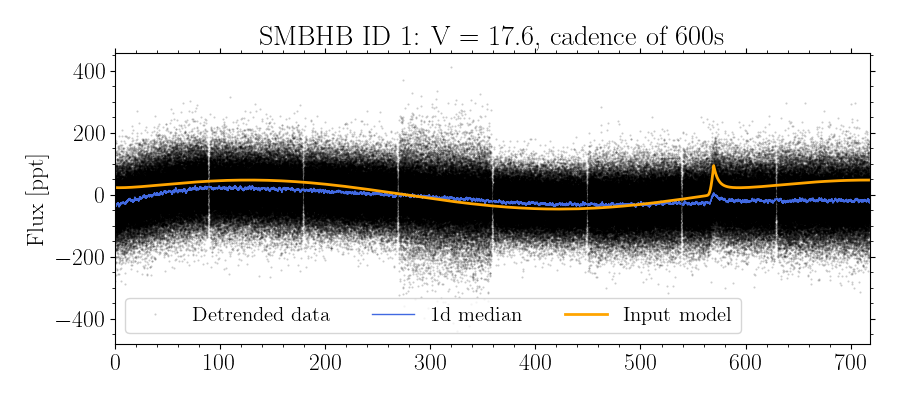

In [128]:
# Calculate median filter
carbox = int(5*24*3600/600)
fmed = median_filter(df.flux, carbox)

# Change time [days]
time   = df.time / 86400.
t_smbh = dv.time / 86400.

# Plot comparison figure
fig, ax = plt.subplots(1, 1, figsize=(9,4))
plt.plot(time, df.flux,  '.', c='k',         ms=1, label='Detrended data', alpha=0.2)
plt.plot(time, fmed,      '-', c='royalblue', lw=1, label='1d median')
plt.plot(t_smbh, dv.flux, '-', c='orange',    lw=2, label='Input model')
plt.title(f'SMBHB ID {ds.ID}: V = {ds.mag:.3}, cadence of 600s')
plt.ylabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(np.min(time), np.max(time))
plt.legend(ncol=3, loc='lower left')
plt.tight_layout();